# Chapter 154 — Matrix Multiplication

> **Prerequisites:** Matrix representation *(ch152)*, matrix addition *(ch153)*, dot product *(ch131)*  
> **You will learn:**
> - Why matrix multiplication is defined the way it is (composition of transformations)
> - The three equivalent ways to read a matrix product
> - Why matrix multiplication is not commutative
> - How to implement matrix multiplication from scratch
> - Performance implications: O(n³) naive, O(n^2.37) theoretical
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Matrix multiplication is not elementwise. It is **function composition**.

If B maps vectors from ℝⁿ to ℝᵏ, and A maps vectors from ℝᵏ to ℝᵐ, then `AB` maps directly from ℝⁿ to ℝᵐ. The product matrix `AB` is the transformation you get by first applying B, then applying A.

The formula `(AB)[i,j] = Σₖ A[i,k] * B[k,j]` is the mechanical description. The geometric description: apply B first, then A.

**Common misconceptions:**
- *"AB = BA."* — False in general. Order matters: different composition order gives different results.
- *"The formula is arbitrary."* — It is forced by the requirement that `(AB)v = A(Bv)` for all v.
- *"Matrix multiplication is slow."* — NumPy's `@` calls optimized BLAS routines and runs near peak hardware throughput.

---

## 2. Intuition & Mental Models

**Geometric:** Think of `AB` as a pipeline. You put a vector in, it goes through B, then through A. The resulting matrix encodes the full pipeline in one step.

**Computational:** Think of `(AB)[i,j]` as the dot product of row i of A with column j of B. Every output entry is one dot product.

**Column view:** Each column of `AB` is `A` applied to the corresponding column of `B`. So `AB` transforms B's columns by A.

Recall from ch054 (Function Composition) that `(f∘g)(x) = f(g(x))`. Matrix multiplication is exactly this, but for linear functions.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_22640\1242626412.py:18: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  circle = np.row_stack([np.cos(t), np.sin(t)])


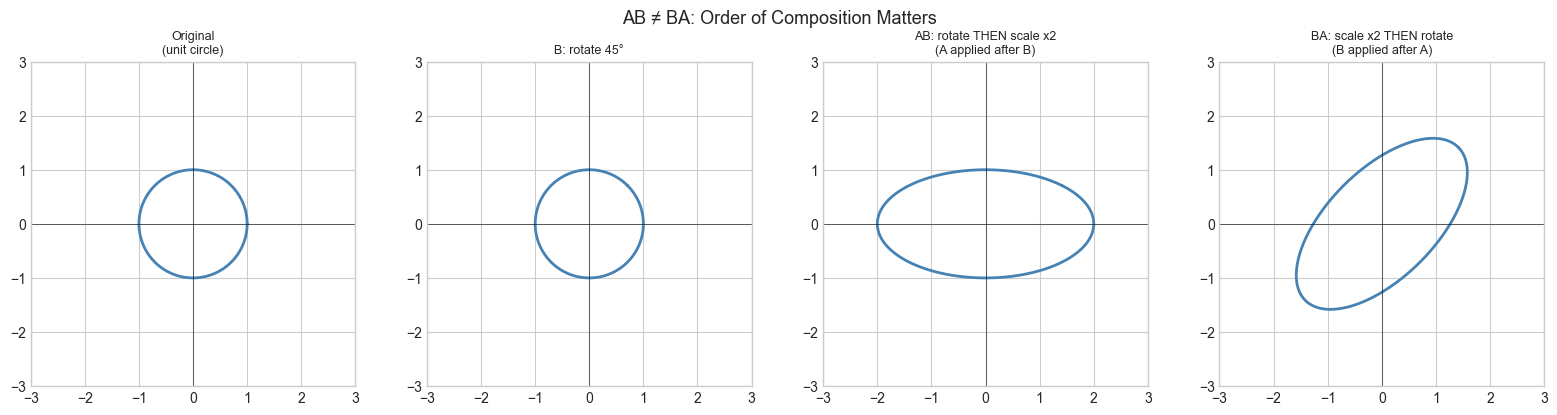

AB =
[[ 1.414 -1.414]
 [ 0.707  0.707]]
BA =
[[ 1.414 -0.707]
 [ 1.414  0.707]]
AB == BA: False


In [1]:
# --- Visualization: AB is composition — apply B first, then A ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

theta = np.pi / 4
# B: rotate 45 degrees
B = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
# A: scale x by 2
A = np.array([[2.0, 0.0], [0.0, 1.0]])
# AB: rotate then scale
AB = A @ B
# BA: scale then rotate  
BA = B @ A

t = np.linspace(0, 2*np.pi, 300)
circle = np.row_stack([np.cos(t), np.sin(t)])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [
    (np.eye(2), 'Original\n(unit circle)'),
    (B,  'B: rotate 45°'),
    (AB, 'AB: rotate THEN scale x2\n(A applied after B)'),
    (BA, 'BA: scale x2 THEN rotate\n(B applied after A)'),
]
for ax, (M, title) in zip(axes, configs):
    result = M @ circle
    ax.plot(result[0], result[1], 'steelblue', lw=2)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_title(title, fontsize=9)

plt.suptitle('AB ≠ BA: Order of Composition Matters', fontsize=13)
plt.tight_layout()
plt.show()

print(f"AB =\n{np.round(AB, 3)}")
print(f"BA =\n{np.round(BA, 3)}")
print(f"AB == BA: {np.allclose(AB, BA)}")

---

## 4. Mathematical Formulation

```
For A (m×k) and B (k×n), the product C = AB is (m×n):

  C[i,j] = Σₗ A[i,l] * B[l,j]   for i=1..m, j=1..n

  ← k terms summed; k is the 'inner dimension' and must match

Three equivalent readings:
  1. C[i,j] = dot(row_i(A), col_j(B))           [row-column dot products]
  2. col_j(C) = A @ col_j(B)                     [A transforms B's columns]
  3. row_i(C) = row_i(A) @ B                     [B transforms A's rows]

Shape rule: (m×k) @ (k×n) = (m×n)   — inner dimensions must match

Associativity: (AB)C = A(BC)         — always true
Commutativity: AB ≠ BA in general    — FALSE for matrices
Distributivity: A(B+C) = AB + AC     — always true
```

In [2]:
# --- Implementation: Matrix multiplication from scratch (three views) ---
import numpy as np

def matmul_ijk(A, B):
    """
    Matrix multiplication: triple-loop (i,j,k) implementation.
    Clearest implementation; not fast.

    Args:
        A: 2D array, shape (m, k)
        B: 2D array, shape (k, n)

    Returns:
        C: 2D array, shape (m, n)
    """
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, f"Inner dims must match: {k} vs {k2}"
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for l in range(k):               # sum over inner dimension
                C[i, j] += A[i, l] * B[l, j]
    return C

def matmul_dot(A, B):
    """
    Matrix multiplication via row-column dot products.
    Vectorized over inner dimension.
    """
    m, k = A.shape
    k2, n = B.shape
    assert k == k2
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            C[i, j] = np.dot(A[i, :], B[:, j])
    return C

def matmul_col(A, B):
    """
    Matrix multiplication via column transformations.
    Each column of C = A applied to column of B.
    """
    m, k = A.shape
    k2, n = B.shape
    assert k == k2
    C = np.zeros((m, n))
    for j in range(n):
        C[:, j] = A @ B[:, j]               # A applied to column j of B
    return C

# Test all three
np.random.seed(42)
A = np.random.randn(4, 3)
B = np.random.randn(3, 5)

C_ijk = matmul_ijk(A, B)
C_dot = matmul_dot(A, B)
C_col = matmul_col(A, B)
C_np  = A @ B

print(f"All implementations match: {np.allclose(C_ijk, C_np) and np.allclose(C_dot, C_np) and np.allclose(C_col, C_np)}")
print(f"Output shape: {C_np.shape}  (from ({A.shape}) @ ({B.shape}))")

All implementations match: True
Output shape: (4, 5)  (from ((4, 3)) @ ((3, 5)))


In [3]:
# --- Performance comparison: scratch vs NumPy ---
import numpy as np
import time

N = 200
A = np.random.randn(N, N)
B = np.random.randn(N, N)

# NumPy (BLAS-optimized)
t0 = time.perf_counter()
for _ in range(20): _ = A @ B
t_np = (time.perf_counter() - t0) / 20

# Our column-view implementation
t0 = time.perf_counter()
_ = matmul_col(A, B)
t_scratch = time.perf_counter() - t0

print(f"NumPy @ (N={N}):    {t_np*1000:.3f} ms")
print(f"Scratch matmul_col: {t_scratch*1000:.3f} ms")
print(f"Speedup: {t_scratch/t_np:.0f}x")
print(f"\nNaive: O(N³) = {N**3:,} operations for N={N}")

NumPy @ (N=200):    0.898 ms
Scratch matmul_col: 4.460 ms
Speedup: 5x

Naive: O(N³) = 8,000,000 operations for N=200


---

## 6. Experiments

In [4]:
# --- Experiment 1: Non-commutativity ---
# Hypothesis: AB - BA is generally non-zero; but for diagonal matrices it IS zero.
# Try changing: use diagonal matrices and see when AB = BA.
import numpy as np

DIAG = False   # <-- set True to make matrices diagonal

np.random.seed(7)
if DIAG:
    A = np.diag(np.random.randn(3))
    B = np.diag(np.random.randn(3))
else:
    A = np.random.randn(3, 3)
    B = np.random.randn(3, 3)

commutator = A @ B - B @ A   # the 'commutator' [A,B]
print(f"Diagonal mode: {DIAG}")
print(f"||AB - BA||_F = {np.linalg.norm(commutator, 'fro'):.4f}")
print(f"Commute: {np.allclose(A@B, B@A)}")

Diagonal mode: False
||AB - BA||_F = 2.1063
Commute: False


In [5]:
# --- Experiment 2: Chaining transformations ---
# Hypothesis: Rotating by θ twice equals rotating by 2θ. (AB = rotation by 2θ)
# Try changing: THETA, N_REPS
import numpy as np

THETA = np.pi / 6    # <-- 30 degrees
N_REPS = 3           # <-- apply rotation N_REPS times

def rot(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

# Compose N_REPS rotations by THETA
R_single = rot(THETA)
R_composed = np.eye(2)
for _ in range(N_REPS):
    R_composed = R_single @ R_composed

R_direct = rot(N_REPS * THETA)

print(f"Composing rotation(θ={np.degrees(THETA):.0f}°) {N_REPS} times:")
print(f"Composed:\n{np.round(R_composed, 6)}")
print(f"Direct rotation({N_REPS}*θ = {np.degrees(N_REPS*THETA):.0f}°):\n{np.round(R_direct, 6)}")
print(f"Equal: {np.allclose(R_composed, R_direct)}")

Composing rotation(θ=30°) 3 times:
Composed:
[[ 0. -1.]
 [ 1.  0.]]
Direct rotation(3*θ = 90°):
[[ 0. -1.]
 [ 1.  0.]]
Equal: True


---

## 7. Exercises

**Easy 1.** What is the shape of `(5×3) @ (3×7)`? What is the shape of `(3×7) @ (5×3)`? Which one is valid?

**Easy 2.** Compute by hand: `[[1,2],[0,1]] @ [[1,0],[1,1]]`. Then compute the reverse order. Are they equal?

**Medium 1.** Implement `matmul_row(A, B)` using the row-view: row i of C = row i of A transformed by B. Verify against `A @ B`.

**Medium 2.** Prove empirically that `(ABC) = (AB)C` (associativity) for three random matrices of compatible shape. Measure timing for both orderings of a large product — sometimes the order of evaluation significantly affects speed. Explain why.

**Hard.** Implement the Strassen algorithm for 2×2 matrix multiplication (7 multiplications instead of 8). Verify correctness. Compute how many multiplications Strassen requires for n×n matrices via recursion vs naive O(n³). At what n does Strassen theoretically become faster, and why is it rarely used in practice?

---

## 8. Mini Project

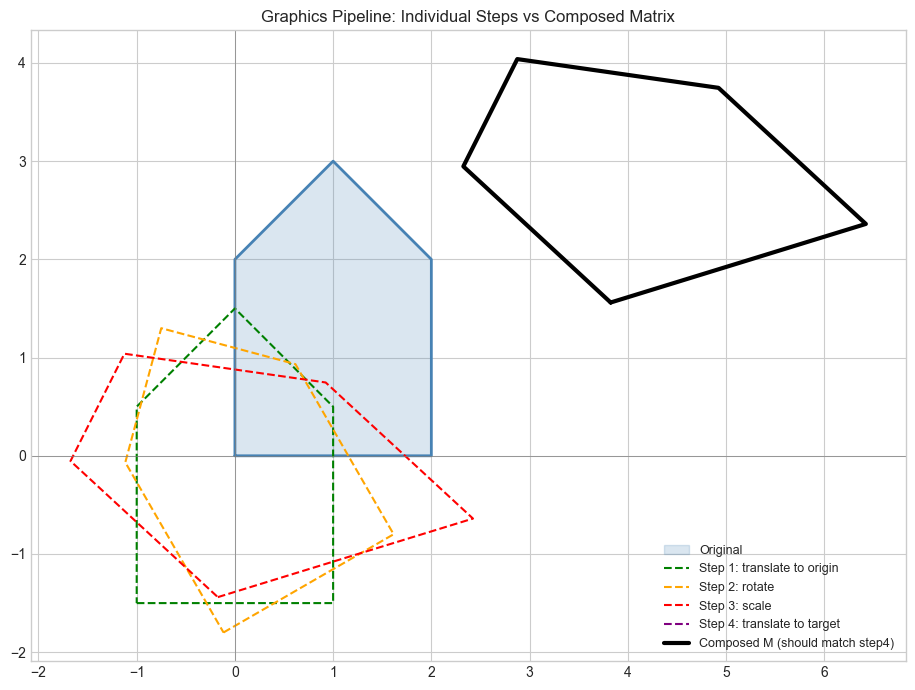

Step-by-step == composed: True


In [6]:
# --- Mini Project: Chain of transformations in a graphics pipeline ---
# Problem: A 2D graphics object is defined as a polygon (list of points).
# Apply a sequence of transformations: translate, rotate, scale.
# Show how composing transformation matrices into one matrix gives the same result.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Object: a simple house shape in homogeneous coordinates [x, y, 1]
# Homogeneous coords allow translation as matrix multiplication (see ch113)
house = np.array([
    [0, 0, 1],  # bottom-left
    [2, 0, 1],  # bottom-right
    [2, 2, 1],  # top-right
    [1, 3, 1],  # roof apex
    [0, 2, 1],  # top-left
    [0, 0, 1],  # close
], dtype=float).T   # shape: (3, 6)

def translate(tx, ty):
    return np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=float)

def rotate_2d(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=float)

def scale_2d(sx, sy):
    return np.array([[sx,0,0],[0,sy,0],[0,0,1]], dtype=float)

# Transformation pipeline: translate to origin, rotate, scale, translate back
T1 = translate(-1, -1.5)         # center the house
R  = rotate_2d(np.pi / 6)        # rotate 30 degrees
S  = scale_2d(1.5, 0.8)          # non-uniform scale
T2 = translate(4, 3)             # move to new position

# Apply step by step
step1 = T1 @ house
step2 = R  @ step1
step3 = S  @ step2
step4 = T2 @ step3

# Compose ALL transformations into ONE matrix
M_composed = T2 @ S @ R @ T1     # read right-to-left: T1 first
composed_result = M_composed @ house

fig, ax = plt.subplots(figsize=(10, 7))
ax.fill(house[0], house[1], alpha=0.2, color='steelblue', label='Original')
ax.plot(house[0], house[1], 'steelblue', lw=2)

for pts, color, label in [
    (step1, 'green',  'Step 1: translate to origin'),
    (step2, 'orange', 'Step 2: rotate'),
    (step3, 'red',    'Step 3: scale'),
    (step4, 'purple', 'Step 4: translate to target'),
]:
    ax.plot(pts[0], pts[1], color=color, lw=1.5, linestyle='--', label=label)

ax.plot(composed_result[0], composed_result[1], 'k-', lw=3, label='Composed M (should match step4)')

ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Graphics Pipeline: Individual Steps vs Composed Matrix')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

print(f"Step-by-step == composed: {np.allclose(step4, composed_result)}")

---

## 9. Chapter Summary & Connections

- Matrix multiplication is function composition: `(AB)v = A(Bv)`. Apply B first, then A.
- The formula `C[i,j] = Σ A[i,k]*B[k,j]` follows necessarily from the composition requirement.
- AB ≠ BA in general; order matters.
- NumPy's `@` operator calls BLAS routines; scratch implementations are 100-1000x slower.
- The homogeneous coordinate trick (3×3 matrices for 2D affine transforms) reappears in ch114 (Affine Transformations) and every graphics/robotics application.

**Backward connection:** This is function composition from ch054 (Function Composition), applied to linear functions.

**Forward connections:**
- In ch157 (Matrix Inverse), we ask: what is the 'undo' matrix? The answer requires AB = I.
- In ch177 (Linear Algebra for Neural Networks), a forward pass is a chain of matrix multiplications — the computational cost analysis here directly governs model training cost.